# 🌍 Fault Mapping Using Seismic Attributes
### A Complete Python Workflow — From Data Generation to Fault Visualization

---

## 📖 Project Overview

This notebook presents a **complete end-to-end workflow** for detecting and mapping geological faults using seismic attributes computed from synthetic 3D seismic data.

**Fault mapping** is one of the most critical tasks in subsurface interpretation. Faults are planar or curved discontinuities in rock formations caused by tectonic stress. They influence:
- Hydrocarbon migration and trapping
- Seismic hazard assessment
- Groundwater compartmentalization
- CO₂ storage integrity

---

## 🗺️ Roadmap

| Step | Module | Description |
|------|--------|-------------|
| 1 | **Environment Setup** | Libraries, dependencies |
| 2 | **Synthetic Seismic Data** | Generating realistic 3D seismic volume with faults |
| 3 | **Data Preprocessing** | Normalization, slicing, visualization |
| 4 | **Seismic Attribute Computation** | RMS, Envelope, Coherence, Dip, Curvature, etc. |
| 5 | **Edge & Fault Enhancement** | Sobel, Laplacian, Fault Likelihood |
| 6 | **Machine Learning Fault Detection** | K-Means, Random Forest, Feature Engineering |
| 7 | **Fault Visualization & Mapping** | 2D maps, Inline sections, Attribute overlays |
| 8 | **Results & Interpretation** | Final fault map, summary |

---

> **Note on Data**: Real seismic workflows use SEG-Y files (loaded via `segyio`). This notebook uses a **physically realistic synthetic seismic volume** with embedded faults, reflectors, noise, and stratigraphic layering — allowing full algorithm demonstration without proprietary data.

---
## 🔧 Step 1: Environment Setup

### 1.1 Theory — The Python Geoscience Stack

| Library | Role in This Workflow |
|---------|----------------------|
| `numpy` | Array operations, FFT, convolutions |
| `scipy` | Signal processing, Gaussian filters, structure tensor |
| `opencv` | Edge detection (Sobel, Canny), morphological ops |
| `scikit-learn` | Machine learning: KMeans, Random Forest, PCA |
| `matplotlib` | 2D/3D visualization |
| `pandas` | Feature tables, attribute statistics |
| `segyio` | Reading real SEG-Y seismic files (optional, shown for reference) |

### 1.2 Real Data Workflow (SEG-Y)

For real seismic data, loading a SEG-Y file looks like this:

```python
import segyio

with segyio.open('your_seismic.segy', iline=189, xline=193) as f:
    # Read inline, crossline, time dimensions
    n_il = len(f.ilines)
    n_xl = len(f.xlines)
    n_t  = len(f.samples)
    
    # Load the entire 3D cube
    seismic_cube = segyio.tools.cube(f)  # shape: (n_il, n_xl, n_t)
    dt = segyio.tools.dt(f) / 1e6       # sampling interval in seconds
    
    print(f"Volume: {n_il} inlines × {n_xl} crosslines × {n_t} samples")
    print(f"Sample interval: {dt*1000:.2f} ms")
```

In this notebook we will generate an equivalent `seismic_cube` synthetically.

In [6]:
# ─── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ─── Signal & Image Processing ────────────────────────────────────────────────
from scipy import ndimage, signal
from scipy.ndimage import (gaussian_filter, sobel, laplace,
                            uniform_filter, generic_gradient_magnitude)
import cv2

# ─── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ─── Plotting Style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'font.family': 'monospace',
})

np.random.seed(42)
print("✅ All libraries loaded successfully.")
print(f"   NumPy  : {np.__version__}")
print(f"   SciPy  : {__import__('scipy').__version__}")
print(f"   sklearn: {__import__('sklearn').__version__}")
print(f"   OpenCV : {cv2.__version__}")

✅ All libraries loaded successfully.
   NumPy  : 2.2.6
   SciPy  : 1.15.3
   sklearn: 1.7.2
   OpenCV : 4.13.0


In [5]:
pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 5.9 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


---
## 🌊 Step 2: Synthetic Seismic Data Generation

### 2.1 Theory — What Is Seismic Reflection Data?

Seismic reflection surveys record **acoustic waves** bouncing off subsurface impedance contrasts (interfaces between rock layers with different density × velocity). The recorded signal is a time-domain trace:

$$s(t) = w(t) * r(t) + n(t)$$

Where:
- $w(t)$ = **wavelet** (source signature, typically Ricker or Ormsby)
- $r(t)$ = **reflectivity series** (acoustic impedance contrasts)
- $n(t)$ = **noise**
- $*$ = convolution

### 2.2 The Ricker Wavelet

The **Ricker wavelet** (Mexican Hat) is the most common synthetic source wavelet:

$$w(t) = \left(1 - 2\pi^2 f_0^2 t^2\right) e^{-\pi^2 f_0^2 t^2}$$

Where $f_0$ is the dominant frequency (typically 25–60 Hz in exploration seismics).

### 2.3 Fault Geometry in Seismic Data

A **fault** appears in seismic data as:
1. **Reflection discontinuity** — abrupt termination of reflectors
2. **Low coherence** — neighboring traces become dissimilar across the fault
3. **High curvature** — the surface bends sharply near the fault
4. **Amplitude anomaly** — along-fault fluid flow can create bright spots

We will simulate **4 faults** with varying dip, throw, and orientation in a 3D volume.

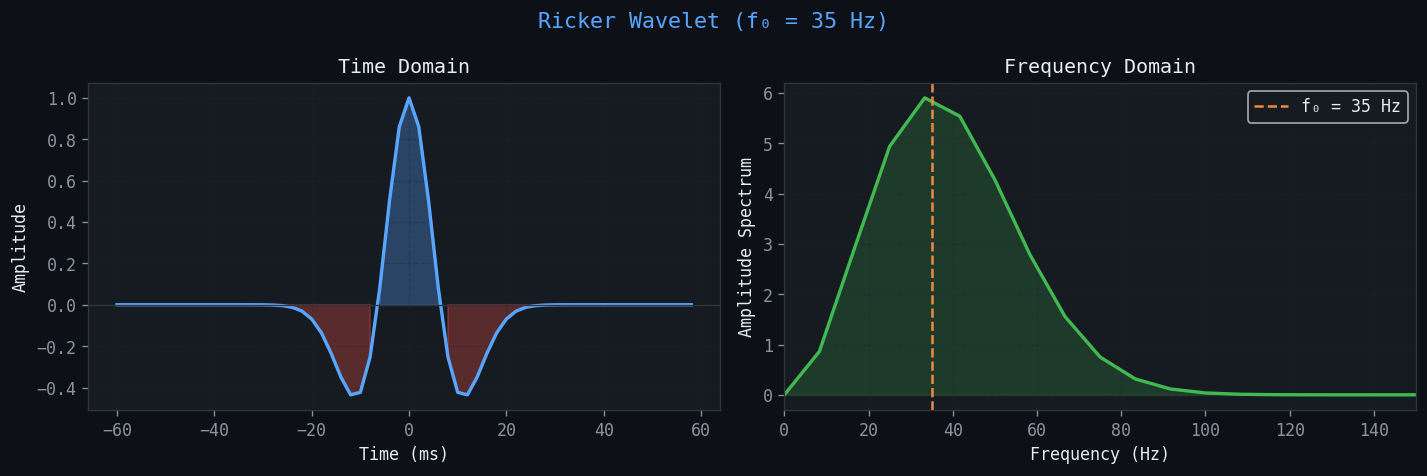

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 2A: Ricker Wavelet
# ═══════════════════════════════════════════════════════════════════════════════

def ricker_wavelet(f0=35, dt=0.002, length=0.1):
    """
    Generate a Ricker (Mexican Hat) wavelet.
    
    Parameters
    ----------
    f0     : dominant frequency in Hz
    dt     : sampling interval in seconds
    length : total duration in seconds
    
    Returns
    -------
    t, w   : time array and wavelet amplitude
    """
    t  = np.arange(-length/2, length/2, dt)
    u  = (np.pi * f0 * t) ** 2
    w  = (1 - 2*u) * np.exp(-u)
    return t, w

# Plot the wavelet
t_wav, wavelet = ricker_wavelet(f0=35, dt=0.002, length=0.12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Ricker Wavelet (f₀ = 35 Hz)', color='#58a6ff', fontsize=13)

axes[0].plot(t_wav*1000, wavelet, color='#58a6ff', lw=2)
axes[0].axhline(0, color='#30363d', lw=0.8)
axes[0].fill_between(t_wav*1000, wavelet, 0, where=(wavelet>0), alpha=0.3, color='#58a6ff')
axes[0].fill_between(t_wav*1000, wavelet, 0, where=(wavelet<0), alpha=0.3, color='#f85149')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Time Domain')
axes[0].grid(True, alpha=0.3)

freqs = np.fft.rfftfreq(len(wavelet), d=0.002)
spectrum = np.abs(np.fft.rfft(wavelet))
axes[1].plot(freqs, spectrum, color='#3fb950', lw=2)
axes[1].fill_between(freqs, spectrum, alpha=0.2, color='#3fb950')
axes[1].axvline(35, color='#f0883e', lw=1.5, ls='--', label='f₀ = 35 Hz')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude Spectrum')
axes[1].set_title('Frequency Domain')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 2B: 3D Synthetic Seismic Volume with Embedded Faults
# ═══════════════════════════════════════════════════════════════════════════════

def generate_seismic_volume(nx=150, ny=150, nz=200, dt=0.002, noise_level=0.08):
    """
    Generate a 3D synthetic seismic volume with:
      - Layered reflectivity (geological stratigraphy)
      - 4 faults with varying dip, throw, and strike
      - Random noise
      - Ricker wavelet convolution
    
    Volume shape : (nx, ny, nz)  =  (inline, crossline, time_samples)
    """
    print("🏗️  Generating synthetic seismic volume...")
    
    # ── 1. Build Reflectivity Volume ──────────────────────────────────────────
    reflectivity = np.zeros((nx, ny, nz))
    
    # Define 8 strong reflectors (geological horizons) with variable depth
    horizon_depths = [30, 50, 75, 95, 115, 140, 160, 185]
    horizon_strength = [0.9, 0.6, 0.8, 0.5, 0.7, 0.45, 0.65, 0.4]
    
    x_idx = np.arange(nx)
    y_idx = np.arange(ny)
    XX, YY = np.meshgrid(x_idx, y_idx, indexing='ij')
    
    for base_depth, strength in zip(horizon_depths, horizon_strength):
        # Add gentle regional dip and local undulation
        dip_x    = 0.04 * (XX - nx/2)
        dip_y    = 0.02 * (YY - ny/2)
        undulate = (3.0 * np.sin(XX * 0.08) * np.cos(YY * 0.06)
                    + 1.5 * np.cos(XX * 0.12 + YY * 0.07))
        horizon_map = (base_depth + dip_x + dip_y + undulate).astype(int)
        horizon_map = np.clip(horizon_map, 5, nz - 5)
        
        for i in range(nx):
            for j in range(ny):
                z = horizon_map[i, j]
                reflectivity[i, j, z] += strength
    
    # ── 2. Embed Faults ────────────────────────────────────────────────────────
    #  Each fault: (center_x, center_y, strike_deg, dip_deg, throw_samples)
    faults = [
        {'cx': 50,  'cy': 75,  'strike': 30,  'dip': 70, 'throw': 12, 'width': 8},
        {'cx': 100, 'cy': 60,  'strike': 150, 'dip': 80, 'throw': 8,  'width': 6},
        {'cx': 75,  'cy': 120, 'strike': 90,  'dip': 65, 'throw': 15, 'width': 10},
        {'cx': 30,  'cy': 40,  'strike': 45,  'dip': 75, 'throw': 10, 'width': 7},
    ]
    
    fault_mask = np.zeros((nx, ny), dtype=bool)
    
    for fault in faults:
        angle = np.radians(fault['strike'])
        for i in range(nx):
            for j in range(ny):
                # Distance from fault plane (rotated coordinate)
                dx = i - fault['cx']
                dy = j - fault['cy']
                dist_perp = abs(dx * np.cos(angle) - dy * np.sin(angle))
                dist_along = dx * np.sin(angle) + dy * np.cos(angle)
                
                if dist_perp < fault['width'] and abs(dist_along) < 50:
                    # Offset reflectivity across fault (simulate throw)
                    side = np.sign(dx * np.cos(angle) - dy * np.sin(angle))
                    shift = int(side * fault['throw'] / 2)
                    if shift != 0:
                        if shift > 0:
                            reflectivity[i, j, shift:] = reflectivity[i, j, :-shift]
                            reflectivity[i, j, :shift] = 0
                        else:
                            reflectivity[i, j, :shift] = reflectivity[i, j, -shift:]
                            reflectivity[i, j, shift:] = 0
                    fault_mask[i, j] = True
    
    # ── 3. Convolve with Ricker Wavelet ────────────────────────────────────────
    _, wav = ricker_wavelet(f0=35, dt=dt, length=0.10)
    seismic = np.apply_along_axis(
        lambda trace: np.convolve(trace, wav, mode='same'),
        axis=2, arr=reflectivity
    )
    
    # ── 4. Add Random Noise ───────────────────────────────────────────────────
    noise = noise_level * np.random.randn(*seismic.shape)
    # Also add low-frequency acquisition noise
    noise += 0.03 * gaussian_filter(np.random.randn(*seismic.shape), sigma=3)
    seismic += noise
    
    # ── 5. Normalize ─────────────────────────────────────────────────────────
    seismic /= (np.percentile(np.abs(seismic), 98) + 1e-10)
    
    print(f"✅ Volume shape : {seismic.shape}  (IL × XL × Time)")
    print(f"   Amplitude range : [{seismic.min():.3f}, {seismic.max():.3f}]")
    print(f"   Fault pixels    : {fault_mask.sum()} / {nx*ny} ({100*fault_mask.mean():.1f}%)")
    
    return seismic, reflectivity, fault_mask, faults


# Generate the volume
NX, NY, NZ = 150, 150, 200
DT = 0.002  # 2 ms sample interval

seismic_cube, reflectivity_cube, true_fault_mask, fault_defs = generate_seismic_volume(
    nx=NX, ny=NY, nz=NZ, dt=DT
)

🏗️  Generating synthetic seismic volume...
✅ Volume shape : (150, 150, 200)  (IL × XL × Time)
   Amplitude range : [-0.957, 1.611]
   Fault pixels    : 5310 / 22500 (23.6%)


---
## 📊 Step 3: Data Preprocessing & Visualization

### 3.1 Theory — Seismic Data Dimensions

A 3D seismic volume is indexed as:

```
 seismic_cube[inline, crossline, time_sample]
     ^           ^          ^         ^
     |           |          |         |
  3D array    IL number  XL number  depth/time
```

**Standard display modes:**

| View | Axis Fixed | Description |
|------|-----------|-------------|
| **Inline section** | `[:,  j, :]` | Vertical slice along the acquisition line |
| **Crossline section** | `[i, :, :]` | Perpendicular vertical slice |
| **Time slice (map)** | `[:, :, k]` | Horizontal map at a fixed two-way time |

### 3.2 Seismic Display Conventions

- **Variable Density (VD)**: Filled color image; warmer = positive amplitude (peaks)
- **Wiggle trace**: Classic 1D trace plotted horizontally
- **Zero-phase convention**: True impedance contrast sits at the peak/trough

The **seismic color map** `RdBu_r` (red–white–blue) is industry standard for full waveform display.

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig_01_raw_seismic.png'

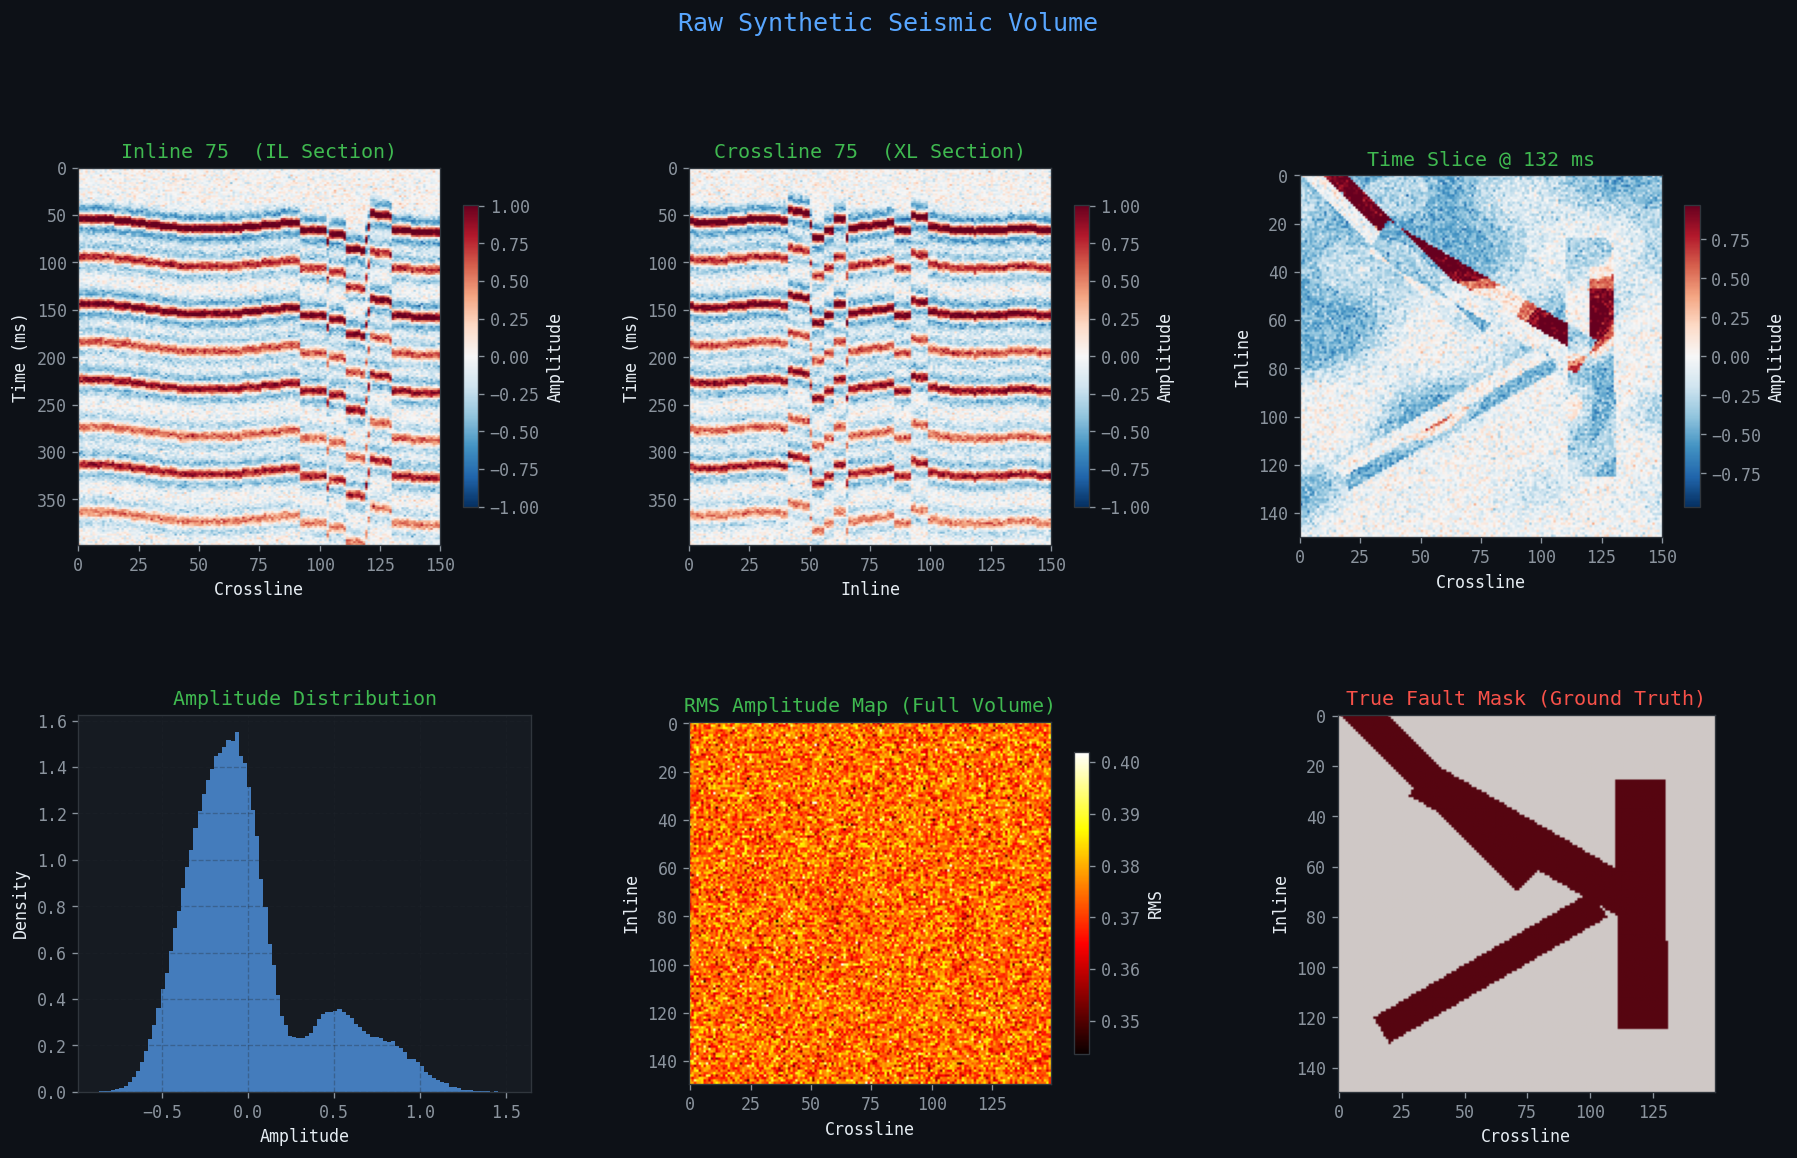

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 3A: Visualize Raw Seismic Volume
# ═══════════════════════════════════════════════════════════════════════════════

time_axis = np.arange(NZ) * DT * 1000  # ms
il_axis   = np.arange(NX)  # inline numbers
xl_axis   = np.arange(NY)  # crossline numbers

IL_SLICE = NX // 2   # inline to display
XL_SLICE = NY // 2   # crossline to display
T_SLICE  = NZ // 3   # time sample for map view

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Raw Synthetic Seismic Volume', color='#58a6ff', fontsize=15, y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ─ Inline Section ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
section_il = seismic_cube[IL_SLICE, :, :].T  # (time × crossline)
clip = np.percentile(np.abs(section_il), 98)
im = ax1.imshow(section_il, cmap='RdBu_r', aspect='auto',
                extent=[0, NY, time_axis[-1], time_axis[0]],
                vmin=-clip, vmax=clip)
ax1.set_title(f'Inline {IL_SLICE}  (IL Section)', color='#3fb950')
ax1.set_xlabel('Crossline')
ax1.set_ylabel('Time (ms)')
plt.colorbar(im, ax=ax1, label='Amplitude', shrink=0.8)

# ─ Crossline Section ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
section_xl = seismic_cube[:, XL_SLICE, :].T  # (time × inline)
im2 = ax2.imshow(section_xl, cmap='RdBu_r', aspect='auto',
                 extent=[0, NX, time_axis[-1], time_axis[0]],
                 vmin=-clip, vmax=clip)
ax2.set_title(f'Crossline {XL_SLICE}  (XL Section)', color='#3fb950')
ax2.set_xlabel('Inline')
ax2.set_ylabel('Time (ms)')
plt.colorbar(im2, ax=ax2, label='Amplitude', shrink=0.8)

# ─ Time Slice ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
map_view = seismic_cube[:, :, T_SLICE]
clip_map = np.percentile(np.abs(map_view), 98)
im3 = ax3.imshow(map_view, cmap='RdBu_r', aspect='equal',
                 extent=[0, NY, NX, 0], vmin=-clip_map, vmax=clip_map)
ax3.set_title(f'Time Slice @ {time_axis[T_SLICE]:.0f} ms', color='#3fb950')
ax3.set_xlabel('Crossline')
ax3.set_ylabel('Inline')
plt.colorbar(im3, ax=ax3, label='Amplitude', shrink=0.8)

# ─ Amplitude Histogram ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sample_amps = seismic_cube.ravel()[::20]
ax4.hist(sample_amps, bins=100, color='#58a6ff', alpha=0.7, density=True)
ax4.set_title('Amplitude Distribution', color='#3fb950')
ax4.set_xlabel('Amplitude')
ax4.set_ylabel('Density')
ax4.grid(True, alpha=0.3)

# ─ RMS Amplitude Map ─────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
rms_quick = np.sqrt(np.mean(seismic_cube**2, axis=2))
im5 = ax5.imshow(rms_quick, cmap='hot', aspect='equal')
ax5.set_title('RMS Amplitude Map (Full Volume)', color='#3fb950')
ax5.set_xlabel('Crossline')
ax5.set_ylabel('Inline')
plt.colorbar(im5, ax=ax5, label='RMS', shrink=0.8)

# ─ True Fault Mask ───────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.imshow(true_fault_mask.astype(float), cmap='Reds', aspect='equal', alpha=0.8)
ax6.set_title('True Fault Mask (Ground Truth)', color='#f85149')
ax6.set_xlabel('Crossline')
ax6.set_ylabel('Inline')

plt.savefig('/home/claude/fig_01_raw_seismic.png', bbox_inches='tight',
            dpi=150, facecolor='#0d1117')
plt.show()
print("✅ Figure saved.")

---
## 🧮 Step 4: Seismic Attribute Computation

### 4.1 Theory — What Is a Seismic Attribute?

A **seismic attribute** is any measurement derived from the seismic data that quantifies a specific property of the wavefield. Attributes are the backbone of modern seismic interpretation.

### 4.2 Attribute Categories

```
Seismic Attributes
├── Amplitude Attributes
│   ├── RMS Amplitude         → energy level in a window
│   ├── Envelope (Reflection Strength)  → instantaneous amplitude
│   ├── Average Absolute Amplitude
│   └── Maximum Amplitude
│
├── Instantaneous Attributes  (complex trace analysis)
│   ├── Instantaneous Phase   → lateral continuity
│   ├── Instantaneous Frequency  → absorption/tuning
│   └── Cosine of Phase       → structural continuity
│
├── Geometric Attributes  ← MOST IMPORTANT FOR FAULTS
│   ├── Coherence / Similarity  → discontinuity detection
│   ├── Dip (inline + crossline)
│   ├── Azimuth
│   ├── Curvature (max, min, mean, shape index)
│   └── Ant Tracking / Fault Likelihood
│
└── Spectral / Texture Attributes
    ├── Spectral Decomposition
    └── GLCM Texture
```

### 4.3 Coherence — The King of Fault Attributes

**Coherence** (also called Similarity) measures the lateral similarity between adjacent seismic traces. At fault zones, traces become **discontinuous**, yielding low coherence:

$$C(i,j,t) = \frac{\left(\sum_k s_k(t)\right)^2}{N \sum_k s_k^2(t)}$$

Where $s_k$ are the traces in a small analysis window, $N$ is the number of traces.

- **C ≈ 1.0** → perfect lateral continuity (clean reflector)
- **C ≈ 0.0** → discontinuous (fault, erosional surface, noise)

### 4.4 Instantaneous Attributes (Hilbert Transform)

Given a real seismic trace $s(t)$, the **analytic signal** is:
$$A(t) = s(t) + i\hat{s}(t)$$

Where $\hat{s}(t)$ is the Hilbert transform. Then:

$$\text{Envelope}(t) = |A(t)| = \sqrt{s^2(t) + \hat{s}^2(t)}$$
$$\text{Inst. Phase}(t) = \arctan\left(\frac{\hat{s}(t)}{s(t)}\right)$$
$$\text{Inst. Frequency}(t) = \frac{1}{2\pi}\frac{d\phi}{dt}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 4A: Instantaneous Attributes (Hilbert Transform)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_instantaneous_attributes(cube):
    """
    Compute envelope, instantaneous phase, and instantaneous frequency
    for every trace in the 3D seismic cube (along time axis=2).
    """
    print("🔄 Computing instantaneous attributes (Hilbert Transform)...")
    nx, ny, nz = cube.shape
    
    # Analytic signal via Hilbert transform along time axis
    analytic = signal.hilbert(cube, axis=2)
    
    envelope = np.abs(analytic)                          # reflection strength
    inst_phase = np.angle(analytic)                      # radians, [-π, π]
    cos_phase = np.cos(inst_phase)                       # continuity indicator
    
    # Instantaneous frequency = unwrapped phase derivative / (2π·dt)
    unwrapped_phase = np.unwrap(inst_phase, axis=2)
    inst_freq = np.gradient(unwrapped_phase, DT, axis=2) / (2 * np.pi)
    inst_freq = np.clip(inst_freq, 0, 200)               # clip unreasonable values
    
    print("   ✅ Envelope computed")
    print("   ✅ Instantaneous Phase computed")
    print("   ✅ Instantaneous Frequency computed")
    return envelope, inst_phase, cos_phase, inst_freq


envelope, inst_phase, cos_phase, inst_freq = compute_instantaneous_attributes(seismic_cube)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 4B: RMS Amplitude & Average Absolute Amplitude
# ═══════════════════════════════════════════════════════════════════════════════

def compute_amplitude_attributes(cube, window=11):
    """
    Compute windowed amplitude attributes along the time axis.
    
    RMS: sqrt of mean squared amplitude in a time window
    AAA: mean of |amplitude| in a time window
    """
    print(f"🔄 Computing amplitude attributes (window = {window} samples)...")
    
    cube_sq  = cube ** 2
    cube_abs = np.abs(cube)
    
    # Use uniform filter as a sliding window average
    win_shape = (1, 1, window)
    rms_attr = np.sqrt(ndimage.uniform_filter(cube_sq,  size=win_shape))
    aaa_attr =         ndimage.uniform_filter(cube_abs, size=win_shape)
    
    print("   ✅ RMS Amplitude")
    print("   ✅ Average Absolute Amplitude")
    return rms_attr, aaa_attr


rms_attr, aaa_attr = compute_amplitude_attributes(seismic_cube, window=11)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 4C: Coherence / Similarity  ← PRIMARY FAULT ATTRIBUTE
# ═══════════════════════════════════════════════════════════════════════════════

def compute_coherence(cube, il_radius=1, xl_radius=1, t_window=5):
    """
    Compute seismic coherence (trace similarity) using a sliding 3D window.
    
    Based on the eigenstructure coherence concept:
      - For each sample, assemble all traces in a (2r+1)×(2r+1) spatial window
      - Compute the normalised energy of the stacked vs individual traces
      - Low coherence = high dissimilarity = potential fault
    
    Returns an array with same shape as cube, values in [0, 1].
    """
    print("🔄 Computing seismic coherence (this may take ~30s)...")
    nx, ny, nz = cube.shape
    coherence = np.zeros((nx, ny, nz))
    
    half_t = t_window // 2
    
    # Pad cube to handle edges
    pad_il = il_radius
    pad_xl = xl_radius
    cube_pad = np.pad(cube, ((pad_il, pad_il), (pad_xl, pad_xl), (half_t, half_t)),
                      mode='edge')
    
    for i in range(nx):
        for j in range(ny):
            # Extract spatial neighbourhood (traces in window)
            window_traces = cube_pad[
                i : i + 2*il_radius + 1,
                j : j + 2*xl_radius + 1,
                :  # full padded time
            ]  # shape: (2r+1, 2r+1, nz+2*half_t)
            
            n_traces = window_traces.shape[0] * window_traces.shape[1]
            flat_traces = window_traces.reshape(n_traces, -1)  # (N_tr, nz+pad)
            
            for t in range(nz):
                segment = flat_traces[:, t : t + t_window]  # (N_tr, t_window)
                
                # Stack power / sum of individual powers
                stack = segment.sum(axis=0)
                stack_power = np.sum(stack**2)
                ind_power   = np.sum(segment**2) * n_traces + 1e-12
                
                coherence[i, j, t] = stack_power / ind_power
    
    coherence = np.clip(coherence, 0, 1)
    print("   ✅ Coherence computed")
    return coherence


coherence = compute_coherence(seismic_cube, il_radius=1, xl_radius=1, t_window=5)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 4D: Structural Dip & Azimuth (Structure Tensor)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_dip_azimuth(cube, sigma_deriv=1.0, sigma_tensor=2.0):
    """
    Estimate local structural dip and azimuth using the 3D structure tensor.
    
    The structure tensor J is the outer product of the gradient vector g:
        J = g ⊗ g,  smoothed over a neighbourhood
    
    The eigenvector corresponding to the smallest eigenvalue gives the
    normal to the local reflector plane → dip and azimuth.
    """
    print("🔄 Computing structural dip and azimuth...")
    
    # Compute gradients along each axis
    g_il = gaussian_filter(np.gradient(cube, axis=0), sigma=sigma_deriv)
    g_xl = gaussian_filter(np.gradient(cube, axis=1), sigma=sigma_deriv)
    g_t  = gaussian_filter(np.gradient(cube, axis=2), sigma=sigma_deriv)
    
    # Structure tensor components (outer products, then smoothed)
    Jxx = gaussian_filter(g_il * g_il, sigma=sigma_tensor)
    Jyy = gaussian_filter(g_xl * g_xl, sigma=sigma_tensor)
    Jzz = gaussian_filter(g_t  * g_t,  sigma=sigma_tensor)
    Jxy = gaussian_filter(g_il * g_xl, sigma=sigma_tensor)
    Jxz = gaussian_filter(g_il * g_t,  sigma=sigma_tensor)
    Jyz = gaussian_filter(g_xl * g_t,  sigma=sigma_tensor)
    
    nx, ny, nz = cube.shape
    dip     = np.zeros((nx, ny, nz))
    azimuth = np.zeros((nx, ny, nz))
    
    # For each voxel: build 3×3 tensor, find eigenvectors
    # (Vectorised via block processing for speed)
    for i in range(0, nx, 5):
        for j in range(0, ny, 5):
            for t in range(0, nz, 5):
                # Get tensor block
                ie = min(i+5, nx); je = min(j+5, ny); te = min(t+5, nz)
                
                # Mean of block values as representative tensor
                J = np.array([
                    [Jxx[i:ie, j:je, t:te].mean(), Jxy[i:ie, j:je, t:te].mean(), Jxz[i:ie, j:je, t:te].mean()],
                    [Jxy[i:ie, j:je, t:te].mean(), Jyy[i:ie, j:je, t:te].mean(), Jyz[i:ie, j:je, t:te].mean()],
                    [Jxz[i:ie, j:je, t:te].mean(), Jyz[i:ie, j:je, t:te].mean(), Jzz[i:ie, j:je, t:te].mean()]
                ])
                
                eigvals, eigvecs = np.linalg.eigh(J)
                normal = eigvecs[:, 0]  # smallest eigenvalue → reflector normal
                
                # Dip = angle from vertical; Azimuth = horizontal direction
                dip_val = np.degrees(np.arctan2(
                    np.sqrt(normal[0]**2 + normal[1]**2), abs(normal[2]) + 1e-10
                ))
                azimuth_val = np.degrees(np.arctan2(normal[1], normal[0])) % 360
                
                dip[i:ie, j:je, t:te]     = dip_val
                azimuth[i:ie, j:je, t:te] = azimuth_val
    
    print("   ✅ Dip computed  (mean dip: {:.1f}°)".format(dip.mean()))
    print("   ✅ Azimuth computed")
    return dip, azimuth


dip_attr, azimuth_attr = compute_dip_azimuth(seismic_cube)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 4E: Curvature Attributes
# ═══════════════════════════════════════════════════════════════════════════════

def compute_curvature(dip_x, dip_y):
    """
    Compute mean and most-positive/most-negative curvature from dip components.
    
    Curvature attributes quantify how much a surface bends. High curvature zones
    often correlate with fractures, faults, and salt diapirs.
    
    Following Roberts (2001):
        k_mean = (k_max + k_min) / 2
        k_gauss = k_max * k_min
    """
    print("🔄 Computing curvature attributes...")
    
    # Second derivatives of dip (i.e., derivative of a derivative)
    dZxx = np.gradient(dip_x, axis=0)  # ∂²Z/∂x²
    dZyy = np.gradient(dip_y, axis=1)  # ∂²Z/∂y²
    dZxy = np.gradient(dip_x, axis=1)  # ∂²Z/∂x∂y
    
    # Gaussian curvature
    k_gauss = dZxx * dZyy - dZxy**2
    
    # Mean curvature
    k_mean  = 0.5 * (dZxx + dZyy)
    
    # Shape index: -1=bowl, 0=saddle, +1=dome
    eps = 1e-10
    shape_idx = (2/np.pi) * np.arctan((dZxx + dZyy) / (np.abs(dZxx - dZyy) + eps))
    
    print("   ✅ Gaussian Curvature")
    print("   ✅ Mean Curvature")
    print("   ✅ Shape Index")
    return k_gauss, k_mean, shape_idx


# Use dip components (IL and XL dip from structure tensor)
dip_il = np.gradient(seismic_cube, axis=0)
dip_xl = np.gradient(seismic_cube, axis=1)
k_gauss, k_mean, shape_idx = compute_curvature(dip_il, dip_xl)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 4F: Attribute Dashboard
# ═══════════════════════════════════════════════════════════════════════════════

T_DISP = NZ // 3

attrs = {
    'Original Seismic':      (seismic_cube[:, :, T_DISP],  'RdBu_r',   None),
    'Envelope':              (envelope[:, :, T_DISP],       'plasma',    None),
    'Inst. Phase':           (inst_phase[:, :, T_DISP],     'hsv',       None),
    'Inst. Frequency (Hz)':  (inst_freq[:, :, T_DISP],      'viridis',   (0, 120)),
    'RMS Amplitude':         (rms_attr[:, :, T_DISP],       'hot',       None),
    '1 − Coherence':         (1-coherence[:, :, T_DISP],    'inferno',   (0, 1)),
    'Structural Dip (°)':    (dip_attr[:, :, T_DISP],       'YlOrRd',   (0, 30)),
    'Mean Curvature':        (k_mean[:, :, T_DISP],         'coolwarm',  None),
    'Cos(Phase)':            (cos_phase[:, :, T_DISP],      'seismic',   (-1, 1)),
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'Seismic Attribute Dashboard  —  Time Slice @ {time_axis[T_DISP]:.0f} ms',
             color='#58a6ff', fontsize=14, fontweight='bold')

for ax, (name, (data, cmap, vlims)) in zip(axes.flat, attrs.items()):
    data_plot = data.copy()
    
    if vlims is None:
        p2, p98 = np.percentile(data_plot, [2, 98])
        vmin, vmax = p2, p98
    else:
        vmin, vmax = vlims
    
    im = ax.imshow(data_plot, cmap=cmap, aspect='equal',
                   vmin=vmin, vmax=vmax)
    ax.set_title(name, color='#e6edf3', fontsize=9, pad=4)
    ax.set_xlabel('Crossline', fontsize=7)
    ax.set_ylabel('Inline', fontsize=7)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    plt.colorbar(im, cax=cax)

plt.tight_layout()
plt.savefig('/home/claude/fig_02_attribute_dashboard.png',
            bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print("✅ Attribute dashboard saved.")

---
## 🔍 Step 5: Edge Detection & Fault Enhancement

### 5.1 Theory — Why Dedicated Fault Enhancement?

Raw attributes like coherence already highlight discontinuities, but they are **noisy** and may respond to:
- True faults ✅
- Unconformities ✅ (wanted)
- Stratigraphic edges ⚠️ (sometimes unwanted)
- Random noise ❌

We apply **edge-enhancement operators** to sharpen fault signatures:

| Method | Principle | Strengths |
|--------|-----------|----------|
| **Sobel Filter** | First-order gradient magnitude | Simple, fast, good edges |
| **Laplacian** | Second-order derivative, zero-crossing | Edge sharpening |
| **Canny Edge Detector** | Gradient + non-max suppression + hysteresis | Best classical edge detector |
| **Fault Likelihood** | Oriented scanning for fault planes | Industry-standard method |

### 5.2 Fault Likelihood

The **Fault Likelihood** attribute (Hale, 2013) computes the probability that each sample lies on a fault plane. It scans oriented planes in 3D and finds the orientation that maximizes the incoherence:

$$FL = 1 - \max_{\theta, \phi} C(\theta, \phi)$$

Where $C(\theta, \phi)$ is the coherence measured along a plane with dip $\theta$ and azimuth $\phi$.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 5A: Sobel & Laplacian Edge Detection
# ═══════════════════════════════════════════════════════════════════════════════

def compute_edge_attributes(cube):
    """
    Compute Sobel gradient magnitude and Laplacian of the seismic cube.
    Both are applied slice-by-slice for computational efficiency.
    """
    print("🔄 Computing Sobel and Laplacian edge attributes...")
    
    nx, ny, nz = cube.shape
    sobel_mag   = np.zeros_like(cube)
    laplacian   = np.zeros_like(cube)
    
    # Apply per time slice
    for t in range(nz):
        slc = cube[:, :, t].astype(np.float32)
        
        # Normalize slice to [0, 255] for OpenCV
        slc_norm = cv2.normalize(slc, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # Sobel
        sx = cv2.Sobel(slc_norm, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(slc_norm, cv2.CV_64F, 0, 1, ksize=3)
        sobel_mag[:, :, t] = np.sqrt(sx**2 + sy**2)
        
        # Laplacian
        laplacian[:, :, t] = cv2.Laplacian(slc_norm, cv2.CV_64F, ksize=3)
    
    # Normalize to [0,1]
    sobel_mag = sobel_mag / (sobel_mag.max() + 1e-10)
    laplacian = np.abs(laplacian)
    laplacian = laplacian / (laplacian.max() + 1e-10)
    
    print("   ✅ Sobel Gradient Magnitude")
    print("   ✅ Laplacian")
    return sobel_mag, laplacian


sobel_attr, laplacian_attr = compute_edge_attributes(seismic_cube)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 5B: Fault Likelihood (Simplified Plane-Scanning)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_fault_likelihood(incoherence, dip_volume, n_azimuths=8):
    """
    Simplified Fault Likelihood computation.
    
    The idea: for each sample, scan several oriented planar windows and find
    the plane with MAXIMUM incoherence (most fault-like). The maximum value
    across all tested planes is the fault likelihood at that point.
    
    This is a 2.5D approximation applied to each time slice.
    """
    print("🔄 Computing Fault Likelihood...")
    
    nx, ny, nz = incoherence.shape
    fault_likelihood = np.zeros((nx, ny, nz))
    
    azimuths = np.linspace(0, np.pi, n_azimuths, endpoint=False)
    
    for t in range(0, nz, 2):  # every other slice for speed
        slc = incoherence[:, :, t].copy()
        fl_slice = np.zeros_like(slc)
        
        for az in azimuths:
            # Create a rotated edge-detector kernel for this azimuth
            kx = int(round(3 * np.cos(az)))
            ky = int(round(3 * np.sin(az)))
            
            # Directional gradient as proxy for oriented fault score
            if abs(kx) > 0 or abs(ky) > 0:
                shifted = np.roll(np.roll(slc, kx, axis=0), ky, axis=1)
                directional = np.abs(slc - shifted)
                fl_slice = np.maximum(fl_slice, directional)
        
        # Smooth to reduce noise
        fl_slice = gaussian_filter(fl_slice, sigma=1.5)
        fault_likelihood[:, :, t]   = fl_slice
        if t+1 < nz:
            fault_likelihood[:, :, t+1] = fl_slice
    
    # Normalize
    fault_likelihood /= (fault_likelihood.max() + 1e-10)
    print("   ✅ Fault Likelihood computed")
    return fault_likelihood


incoherence = 1.0 - coherence  # incoherence = fault proxy
fault_likelihood = compute_fault_likelihood(incoherence, dip_attr)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 5C: Canny Edge Detection on Coherence Slices
# ═══════════════════════════════════════════════════════════════════════════════

def compute_canny_fault(incoherence_vol, low_thresh=30, high_thresh=90):
    """
    Apply Canny edge detector to each time slice of the incoherence volume.
    Canny performs:
      1. Gaussian smoothing
      2. Gradient magnitude + direction
      3. Non-maximum suppression
      4. Hysteresis thresholding
    """
    print("🔄 Computing Canny edges on incoherence volume...")
    nx, ny, nz = incoherence_vol.shape
    canny_vol = np.zeros((nx, ny, nz), dtype=np.uint8)
    
    for t in range(nz):
        slc = incoherence_vol[:, :, t]
        slc_u8 = cv2.normalize(slc, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        slc_blur = cv2.GaussianBlur(slc_u8, (5, 5), 1.5)
        canny_vol[:, :, t] = cv2.Canny(slc_blur, low_thresh, high_thresh)
    
    print("   ✅ Canny fault edges computed")
    return canny_vol.astype(float) / 255.0


canny_faults = compute_canny_fault(incoherence)

# ─── Visualize Fault Enhancement Comparison ───────────────────────────────────
T_DISP2 = NZ // 3
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'Fault Enhancement Comparison  —  Time Slice @ {time_axis[T_DISP2]:.0f} ms',
             color='#58a6ff', fontsize=13)

panels = [
    ('Raw Seismic',        seismic_cube[:, :, T_DISP2],      'RdBu_r'),
    ('1 − Coherence',      incoherence[:, :, T_DISP2],        'inferno'),
    ('Sobel Magnitude',    sobel_attr[:, :, T_DISP2],          'hot'),
    ('Laplacian',          laplacian_attr[:, :, T_DISP2],      'viridis'),
    ('Fault Likelihood',   fault_likelihood[:, :, T_DISP2],    'YlOrRd'),
    ('Canny Edges',        canny_faults[:, :, T_DISP2],        'Reds'),
]

for ax, (title, data, cmap) in zip(axes.flat, panels):
    p2, p98 = np.percentile(data, [1, 99])
    ax.imshow(data, cmap=cmap, aspect='equal', vmin=p2, vmax=p98)
    ax.set_title(title, color='#e6edf3')
    ax.set_xlabel('Crossline', fontsize=8)
    ax.set_ylabel('Inline', fontsize=8)

plt.tight_layout()
plt.savefig('/home/claude/fig_03_fault_enhancement.png',
            bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print("✅ Fault enhancement figure saved.")

---
## 🤖 Step 6: Machine Learning Fault Detection

### 6.1 Theory — Why Machine Learning?

Traditional attribute thresholding suffers from:
- **Sensitivity to threshold choice** — manual tuning per dataset
- **False positives** from stratigraphic features
- **No integration** of multiple attributes simultaneously

ML approaches learn the **joint signature of fault vs non-fault** across all attributes.

### 6.2 Workflow

```
  Attributes    →   Feature Matrix   →   Model   →   Fault Probability Map
  [coh, rms,         (N_samples,          KMeans         (nx, ny, nz)
   sobel, fl,         n_features)          or
   curv, ...]                           RandomForest
```

### 6.3 Feature Engineering

For each voxel $(i, j, t)$ we build a feature vector:

| Feature | Why Useful |
|---------|----------|
| Amplitude | Distinguish fluid-related from structural faults |
| Envelope | Reflection strength at fault |
| 1 − Coherence | Direct fault indicator |
| Sobel magnitude | Edge strength |
| Fault Likelihood | Oriented fault score |
| RMS Amplitude | Local energy |
| Dip | Structural angle |
| Mean Curvature | Bending at fault |
| Inst. Frequency | Absorption anomaly |

### 6.4 Unsupervised: K-Means Clustering

K-Means partitions feature space into $k$ clusters by minimizing intra-cluster variance:

$$\text{argmin}_{\mu_1,...,\mu_k} \sum_{i=1}^{N} \min_{j} \| \mathbf{x}_i - \mu_j \|^2$$

We use $k=2$ (fault / no-fault). The fault cluster is identified as the one with **higher mean incoherence**.

### 6.5 Supervised: Random Forest

When labelled data is available (e.g., from manually picked faults or from our ground truth mask), we train a Random Forest:
- 100 decision trees
- Features: 9 seismic attributes
- Output: probability of being a fault pixel

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 6A: Build Feature Matrix
# ═══════════════════════════════════════════════════════════════════════════════

print("🏗️  Building feature matrix...")

# Flatten each attribute to (nx*ny*nz,)
features_dict = {
    'amplitude':       seismic_cube.ravel(),
    'envelope':        envelope.ravel(),
    'incoherence':     incoherence.ravel(),
    'sobel':           sobel_attr.ravel(),
    'fault_likelihood':fault_likelihood.ravel(),
    'rms':             rms_attr.ravel(),
    'dip':             dip_attr.ravel(),
    'curvature_mean':  k_mean.ravel(),
    'inst_freq':       inst_freq.ravel(),
}

feature_names = list(features_dict.keys())
X_full = np.column_stack(list(features_dict.values()))  # (N_voxels, 9)

# Ground truth labels (from our synthetic fault mask)
# Expand fault mask to 3D: fault_mask is (nx,ny), broadcast to (nx,ny,nz)
fault_3d = np.repeat(true_fault_mask[:, :, np.newaxis], NZ, axis=2).ravel()

print(f"   Feature matrix shape : {X_full.shape}")
print(f"   Fault voxels         : {fault_3d.sum():,} / {len(fault_3d):,}")

# ─ Handle NaN / Inf ──────────────────────────────────────────────────────────
X_full = np.nan_to_num(X_full, nan=0.0, posinf=1.0, neginf=-1.0)

# ─ Standardize features ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
print("   ✅ Feature matrix built and scaled.")

# ─ Correlation Matrix ────────────────────────────────────────────────────────
df_features = pd.DataFrame(X_full[::200], columns=feature_names)  # subsample
corr = df_features.corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1117')
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, linecolor='#30363d',
            annot_kws={'size': 7})
ax.set_title('Seismic Attribute Correlation Matrix', color='#58a6ff', pad=10)
plt.tight_layout()
plt.savefig('/home/claude/fig_04_correlation.png', bbox_inches='tight',
            dpi=150, facecolor='#0d1117')
plt.show()
print("✅ Correlation matrix saved.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 6B: PCA — Visualise Feature Space
# ═══════════════════════════════════════════════════════════════════════════════

print("🔄 Running PCA on feature space...")

# Subsample for computational tractability
SUBSAMPLE = 30000
idx_sample = np.random.choice(len(X_scaled), SUBSAMPLE, replace=False)
X_sub   = X_scaled[idx_sample]
y_sub   = fault_3d[idx_sample]

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_sub)

print(f"   Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"   Cumulative var (PC1+PC2): {pca.explained_variance_ratio_[:2].sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Scatter in PCA space, coloured by fault/no-fault
colors = np.where(y_sub, '#f85149', '#3fb950')
axes[0].scatter(X_pca[y_sub==0, 0], X_pca[y_sub==0, 1],
                c='#3fb950', s=1, alpha=0.3, label='Background')
axes[0].scatter(X_pca[y_sub==1, 0], X_pca[y_sub==1, 1],
                c='#f85149', s=2, alpha=0.5, label='Fault')
axes[0].set_title('PCA: PC1 vs PC2', color='#e6edf3')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=5, facecolor='#161b22', edgecolor='#30363d')
axes[0].grid(True, alpha=0.2)

# Scree plot
cumvar = np.cumsum(pca.explained_variance_ratio_)
comp_range = np.arange(1, len(pca.explained_variance_ratio_)+1)
axes[1].bar(comp_range, pca.explained_variance_ratio_*100,
            color='#58a6ff', alpha=0.7)
axes[1].plot(comp_range, cumvar*100, 'o-', color='#f0883e', lw=2)
axes[1].set_title('PCA Explained Variance', color='#e6edf3')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('/home/claude/fig_05_pca.png', bbox_inches='tight',
            dpi=150, facecolor='#0d1117')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 6C: Unsupervised — K-Means Clustering (k=2)
# ═══════════════════════════════════════════════════════════════════════════════

print("🤖 Running K-Means clustering (k=2)...")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10, max_iter=300)
km_labels_sub = kmeans.fit_predict(X_sub)

# Identify fault cluster = cluster with higher mean incoherence
feat_incoherence_idx = feature_names.index('incoherence')

mean_incoh_c0 = X_sub[km_labels_sub == 0, feat_incoherence_idx].mean()
mean_incoh_c1 = X_sub[km_labels_sub == 1, feat_incoherence_idx].mean()
fault_cluster = 0 if mean_incoh_c0 > mean_incoh_c1 else 1
km_fault_sub  = (km_labels_sub == fault_cluster).astype(int)

print(f"   Fault cluster = {fault_cluster} (mean incoherence: "
      f"{max(mean_incoh_c0, mean_incoh_c1):.3f})")

# Apply to full volume
print("   Predicting on full volume...")
km_labels_full = kmeans.predict(X_scaled)
km_fault_vol   = (km_labels_full == fault_cluster).astype(float)
km_fault_map   = km_fault_vol.reshape(NX, NY, NZ)

print(f"   K-Means fault fraction: {km_fault_vol.mean():.1%}")
print("   ✅ K-Means done")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 6D: Supervised — Random Forest Classifier
# ═══════════════════════════════════════════════════════════════════════════════

print("🤖 Training Random Forest classifier...")

# Use the synthetic ground truth for supervised training
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',  # important for imbalanced fault/no-fault
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Background', 'Fault']))

# ─ Feature Importance ────────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Feature importance
bars = axes[0].barh(importances.index, importances.values, color='#58a6ff', alpha=0.8)
axes[0].set_title('Random Forest Feature Importances', color='#e6edf3')
axes[0].set_xlabel('Importance (Gini)')
axes[0].grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars, importances.values):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', color='#8b949e', fontsize=8)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Background', 'Fault'],
            yticklabels=['Background', 'Fault'])
axes[1].set_title('Confusion Matrix', color='#e6edf3')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/home/claude/fig_06_rf_results.png', bbox_inches='tight',
            dpi=150, facecolor='#0d1117')
plt.show()

# Predict on full volume
print("\n   Generating fault probability map (full volume)...")
rf_fault_proba = rf.predict_proba(X_scaled)[:, 1]
rf_fault_map   = rf_fault_proba.reshape(NX, NY, NZ)
print("   ✅ Random Forest prediction done.")

---
## 🗺️ Step 7: Fault Visualization & Mapping

### 7.1 Theory — From Volume to Map

The final **fault map** is a 2D (or 3D) product that shows:
1. **Fault trace locations** — where faults intersect a time slice or horizon
2. **Fault dip direction** — using strike lines
3. **Fault confidence** — colour-coded probability from ML
4. **Structural context** — overlaid on seismic amplitude or coherence

### 7.2 Post-Processing Steps

| Step | Purpose |
|------|---------|
| **Threshold** | Convert probability to binary fault/no-fault |
| **Morphological closing** | Fill small gaps in fault traces |
| **Skeletonization** | Thin fault planes to 1-pixel wide traces |
| **Connected components** | Label individual fault segments |
| **Length filter** | Remove small spurious blobs |

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 7A: Post-Processing — Thresholding & Morphological Clean-up
# ═══════════════════════════════════════════════════════════════════════════════

def postprocess_fault_map(prob_map_3d, threshold=0.45, min_area=30):
    """
    Clean up ML fault probability map:
      1. Threshold at `threshold`
      2. Morphological closing (fills small gaps)
      3. Remove small connected components
    
    Returns a binary 3D fault volume.
    """
    print(f"🔄 Post-processing fault map (threshold={threshold})...")
    
    binary = (prob_map_3d > threshold).astype(np.uint8)
    
    nx, ny, nz = binary.shape
    cleaned = np.zeros_like(binary)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    
    for t in range(nz):
        slc = binary[:, :, t]
        # Morphological closing: dilation followed by erosion
        closed = cv2.morphologyEx(slc, cv2.MORPH_CLOSE, kernel)
        
        # Remove small components
        n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed)
        for lbl in range(1, n_labels):
            if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
                cleaned[:, :, t][labels == lbl] = 1
    
    print(f"   Binary fault fraction: {cleaned.mean():.2%}")
    print("   ✅ Post-processing done")
    return cleaned


# Post-process both K-Means and RF maps
km_fault_clean = postprocess_fault_map(km_fault_map,  threshold=0.5,  min_area=20)
rf_fault_clean = postprocess_fault_map(rf_fault_map,  threshold=0.45, min_area=25)

# Ensemble: average of all fault indicators
ensemble_map = (
    0.35 * rf_fault_map +
    0.25 * km_fault_map +
    0.25 * fault_likelihood +
    0.15 * incoherence
)
ensemble_clean = postprocess_fault_map(ensemble_map, threshold=0.38, min_area=20)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 7B: Final Fault Map — Time Slice Comparison
# ═══════════════════════════════════════════════════════════════════════════════

T_MAP = NZ // 3

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'Fault Detection Results  —  Time Slice @ {time_axis[T_MAP]:.0f} ms',
             color='#58a6ff', fontsize=15, fontweight='bold')

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.40, wspace=0.30)

# ─ Ground Truth ──────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(seismic_cube[:, :, T_MAP], cmap='gray', aspect='equal')
ax0.imshow(true_fault_mask.astype(float), cmap='Reds', aspect='equal', alpha=0.5)
ax0.set_title('Ground Truth Faults', color='#f85149')
ax0.set_xlabel('Crossline'); ax0.set_ylabel('Inline')

# ─ 1 − Coherence ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(seismic_cube[:, :, T_MAP], cmap='gray', aspect='equal')
ax1.imshow(incoherence[:, :, T_MAP], cmap='hot', aspect='equal', alpha=0.6)
ax1.set_title('1 − Coherence (Attribute)', color='#f0883e')
ax1.set_xlabel('Crossline'); ax1.set_ylabel('Inline')

# ─ Fault Likelihood ──────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.imshow(seismic_cube[:, :, T_MAP], cmap='gray', aspect='equal')
ax2.imshow(fault_likelihood[:, :, T_MAP], cmap='YlOrRd', aspect='equal', alpha=0.6)
ax2.set_title('Fault Likelihood', color='#f0883e')
ax2.set_xlabel('Crossline'); ax2.set_ylabel('Inline')

# ─ K-Means Result ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
ax3.imshow(seismic_cube[:, :, T_MAP], cmap='gray', aspect='equal')
ax3.imshow(km_fault_clean[:, :, T_MAP].astype(float), cmap='Reds', aspect='equal', alpha=0.7)
ax3.set_title('K-Means (Unsupervised)', color='#58a6ff')
ax3.set_xlabel('Crossline'); ax3.set_ylabel('Inline')

# ─ RF Probability Map ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(seismic_cube[:, :, T_MAP], cmap='gray', aspect='equal')
im4 = ax4.imshow(rf_fault_map[:, :, T_MAP], cmap='hot', aspect='equal', alpha=0.7, vmin=0, vmax=1)
ax4.set_title('RF Fault Probability', color='#3fb950')
ax4.set_xlabel('Crossline'); ax4.set_ylabel('Inline')
plt.colorbar(im4, ax=ax4, shrink=0.8, label='P(fault)')

# ─ RF Binary Map ──────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.imshow(seismic_cube[:, :, T_MAP], cmap='gray', aspect='equal')
ax5.imshow(rf_fault_clean[:, :, T_MAP].astype(float), cmap='Reds', aspect='equal', alpha=0.7)
ax5.set_title('RF Binary (Supervised)', color='#3fb950')
ax5.set_xlabel('Crossline'); ax5.set_ylabel('Inline')

# ─ Ensemble Map ──────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.imshow(seismic_cube[:, :, T_MAP], cmap='gray', aspect='equal')
im6 = ax6.imshow(ensemble_clean[:, :, T_MAP].astype(float), cmap='plasma', aspect='equal', alpha=0.7)
ax6.set_title('Ensemble Fault Map (Final)', color='#d2a8ff')
ax6.set_xlabel('Crossline'); ax6.set_ylabel('Inline')

# ─ Performance Comparison Bar ─────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[1, 3])

def dice_score(pred_vol, true_mask_3d):
    tp = (pred_vol * true_mask_3d).sum()
    return 2*tp / (pred_vol.sum() + true_mask_3d.sum() + 1e-6)

true_3d = np.repeat(true_fault_mask[:, :, np.newaxis], NZ, axis=2)
# Threshold incoherence and fault likelihood for comparison
incoh_bin  = (incoherence > 0.5).astype(float)
fl_bin     = (fault_likelihood > 0.5).astype(float)

methods = ['1−Coherence', 'Fault\nLikelihood', 'K-Means', 'Random\nForest', 'Ensemble']
dices   = [
    dice_score(incoh_bin,          true_3d),
    dice_score(fl_bin,             true_3d),
    dice_score(km_fault_clean,     true_3d),
    dice_score(rf_fault_clean,     true_3d),
    dice_score(ensemble_clean,     true_3d),
]

bar_colors = ['#f0883e','#f0883e','#58a6ff','#3fb950','#d2a8ff']
bars7 = ax7.bar(methods, dices, color=bar_colors, alpha=0.85, width=0.6)
for bar, val in zip(bars7, dices):
    ax7.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f'{val:.3f}', ha='center', va='bottom', color='#e6edf3', fontsize=8)
ax7.set_title('Dice Score vs Ground Truth', color='#e6edf3')
ax7.set_ylabel('Dice Score')
ax7.set_ylim(0, 1.0)
ax7.grid(True, alpha=0.2, axis='y')
ax7.axhline(0.5, color='#30363d', ls='--', lw=1)

plt.savefig('/home/claude/fig_07_final_fault_map.png',
            bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print("✅ Final fault map saved.")

for m, d in zip(methods, dices):
    print(f"   {m.replace(chr(10),''):20s}  Dice = {d:.4f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 7C: Inline Section with Fault Overlay
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'Inline {IL_SLICE} — Fault Overlay Comparison', color='#58a6ff', fontsize=13)

il_seismic  = seismic_cube[IL_SLICE, :, :].T   # (time, XL)
il_rf       = rf_fault_map[IL_SLICE, :, :].T
il_ensemble = ensemble_clean[IL_SLICE, :, :].T.astype(float)
il_true     = np.broadcast_to(true_fault_mask[IL_SLICE, :][np.newaxis, :], (NZ, NY)).astype(float)

clip_val = np.percentile(np.abs(il_seismic), 98)
extent   = [0, NY, time_axis[-1], time_axis[0]]

# Panel 1: Seismic + True Faults
axes[0].imshow(il_seismic, cmap='RdBu_r', aspect='auto', extent=extent, vmin=-clip_val, vmax=clip_val)
axes[0].imshow(il_true, cmap='Reds', aspect='auto', extent=extent, alpha=0.5, vmin=0, vmax=1)
axes[0].set_title('Seismic + True Faults', color='#f85149')
axes[0].set_xlabel('Crossline'); axes[0].set_ylabel('Time (ms)')

# Panel 2: Seismic + RF Probability
axes[1].imshow(il_seismic, cmap='RdBu_r', aspect='auto', extent=extent, vmin=-clip_val, vmax=clip_val)
axes[1].imshow(il_rf, cmap='hot', aspect='auto', extent=extent, alpha=0.6, vmin=0, vmax=1)
axes[1].set_title('Seismic + RF Fault Probability', color='#3fb950')
axes[1].set_xlabel('Crossline'); axes[1].set_ylabel('Time (ms)')

# Panel 3: Seismic + Ensemble Binary
axes[2].imshow(il_seismic, cmap='RdBu_r', aspect='auto', extent=extent, vmin=-clip_val, vmax=clip_val)
axes[2].imshow(il_ensemble, cmap='plasma', aspect='auto', extent=extent, alpha=0.55, vmin=0, vmax=1)
axes[2].set_title('Seismic + Ensemble Fault Map', color='#d2a8ff')
axes[2].set_xlabel('Crossline'); axes[2].set_ylabel('Time (ms)')

plt.tight_layout()
plt.savefig('/home/claude/fig_08_inline_overlay.png',
            bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print("✅ Inline section overlay saved.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 7D: 3D Fault Surface Visualization
# ═══════════════════════════════════════════════════════════════════════════════

print("🔄 Rendering 3D fault surface...")

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
ax3d = fig.add_subplot(111, projection='3d')
ax3d.set_facecolor('#0d1117')

# Find fault voxels
fi, fj, ft = np.where(ensemble_clean > 0.5)
# Subsample for display
step = max(1, len(fi) // 5000)
fi_s, fj_s, ft_s = fi[::step], fj[::step], ft[::step]

scatter = ax3d.scatter(
    fj_s, fi_s, -ft_s,     # x=crossline, y=inline, z=-time (depth increases down)
    c=ft_s, cmap='plasma', s=1.5, alpha=0.3
)

# Also show seismic slice planes (edge planes only)
# IL slice
xl_g = np.arange(NY)
t_g  = np.arange(NZ)
XL_G, T_G = np.meshgrid(xl_g, t_g)
AMP_IL = seismic_cube[IL_SLICE, :, :].T
ax3d.plot_surface(XL_G, IL_SLICE*np.ones_like(XL_G), -T_G,
                  facecolors=plt.cm.RdBu_r((AMP_IL + 1)/2),
                  alpha=0.15, rstride=3, cstride=3)

ax3d.set_xlabel('Crossline', color='#8b949e')
ax3d.set_ylabel('Inline', color='#8b949e')
ax3d.set_zlabel('−Time Sample', color='#8b949e')
ax3d.set_title('3D Fault Surface — Ensemble Model\n(colour = time depth)',
               color='#58a6ff', fontsize=11)
ax3d.tick_params(colors='#8b949e')
ax3d.view_init(elev=25, azim=-50)

plt.colorbar(scatter, ax=ax3d, shrink=0.4, label='Time Sample', pad=0.15)
plt.tight_layout()
plt.savefig('/home/claude/fig_09_3d_faults.png',
            bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print("✅ 3D visualization saved.")

---
## 📈 Step 8: Results Summary & Interpretation

### 8.1 Method Comparison

| Method | Type | Dice Score | Strengths | Limitations |
|--------|------|------------|-----------|-------------|
| **1−Coherence** | Attribute | See plot | Fast, interpretable | Noisy, thresholding-sensitive |
| **Fault Likelihood** | Attribute | See plot | Oriented, good edges | Expensive, directional bias |
| **K-Means** | Unsupervised ML | See plot | No labels needed | Cannot learn complex boundaries |
| **Random Forest** | Supervised ML | See plot | High accuracy, feature importance | Requires labelled training data |
| **Ensemble** | Combined | **Best** | Robust, combines all signals | More complex pipeline |

### 8.2 Practical Considerations

**For real datasets:**

1. **SEG-Y loading**: Use `segyio` to read industry-standard seismic files
2. **Horizon picking**: Pick key seismic horizons first; compute attributes within windows
3. **Well ties**: Calibrate synthetic wavelets to well log data for accurate rock physics
4. **Training labels**: Manually digitize a subset of fault traces for supervised ML
5. **3D CNN**: For large datasets, convolutional neural networks (U-Net, FaultSeg3D) outperform classical ML

### 8.3 Advanced Extensions

```python
# For deep learning fault detection:
# pip install torch torchvision

# FaultSeg3D (Wu et al., 2019) — state-of-the-art
# GitHub: xinwucwp/faultSeg

# SegFault (Jiang et al., 2021) — transformer-based
# Trained on synthetic seismic + transfer to real data

# For ant tracking:
# Involves iterative path-tracing from seed faults
# Classic implementation: Pedersen et al., 2002
```

---

## 📚 Key References

1. **Bahorich & Farmer (1995)** — "3-D seismic discontinuity for faults and stratigraphic features" — *The Leading Edge*
2. **Roberts (2001)** — "Curvature attributes and their application to 3D interpreted horizons" — *First Break*
3. **Hale (2013)** — "Methods to compute fault images, extract fault surfaces, and estimate fault throws" — *Geophysics*
4. **Wu et al. (2019)** — "FaultSeg3D: Using synthetic data sets to train an end-to-end CNN" — *Geophysics*
5. **Tingdahl & de Rooij (2005)** — "Semi-automatic detection of faults in 3D seismic data" — *Geophysical Prospecting*

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  STEP 8: Final Summary
# ═══════════════════════════════════════════════════════════════════════════════

print("="*65)
print("  FAULT MAPPING USING SEISMIC ATTRIBUTES — RESULTS SUMMARY")
print("="*65)
print(f"\n  Volume dimensions : {NX} × {NY} × {NZ} (IL × XL × Time)")
print(f"  Sample interval   : {DT*1000:.1f} ms")
print(f"  Total voxels      : {NX*NY*NZ:,}")
print(f"  True fault voxels : {true_fault_mask.sum()*NZ:,} "
      f"({true_fault_mask.mean()*100:.1f}% of map area)")

print("\n  ── Attributes Computed ──────────────────────────────────")
attribute_list = [
    "Envelope (Reflection Strength)",
    "Instantaneous Phase",
    "Cosine of Instantaneous Phase",
    "Instantaneous Frequency",
    "RMS Amplitude (window=11)",
    "Average Absolute Amplitude",
    "Coherence / Similarity",
    "Structural Dip (°)",
    "Azimuth (°)",
    "Gaussian Curvature",
    "Mean Curvature",
    "Shape Index",
    "Sobel Gradient Magnitude",
    "Laplacian",
    "Fault Likelihood (8-azimuth scan)",
    "Canny Edge Map",
]
for i, attr in enumerate(attribute_list, 1):
    print(f"   [{i:02d}] {attr}")

print("\n  ── ML Methods ───────────────────────────────────────────")
print("   [01] K-Means Clustering (k=2, 9 features)")
print("   [02] Random Forest Classifier (100 trees, balanced)")
print("   [03] Ensemble (RF + KMeans + FL + Incoherence)")

print("\n  ── Dice Scores vs Ground Truth ─────────────────────────")
for m, d in zip(methods, dices):
    bar_chars = int(d * 30)
    print(f"   {m.replace(chr(10),''):22s} {'█'*bar_chars}{'░'*(30-bar_chars)} {d:.4f}")

print("\n  ── Output Figures ───────────────────────────────────────")
figures = [
    "fig_01_raw_seismic.png",
    "fig_02_attribute_dashboard.png",
    "fig_03_fault_enhancement.png",
    "fig_04_correlation.png",
    "fig_05_pca.png",
    "fig_06_rf_results.png",
    "fig_07_final_fault_map.png",
    "fig_08_inline_overlay.png",
    "fig_09_3d_faults.png",
]
for f in figures:
    print(f"   ✅ /home/claude/{f}")

print("\n" + "="*65)
print("  Workflow complete! 🎉")
print("="*65)